In [36]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("loan_data.csv")
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [3]:
cat_var = [
    var for var in df.columns[:-2] 
    if df[var].nunique() < 10
]


cat_columns = [pd.get_dummies(df[col], prefix=col) for col in cat_var]
df = df.join(cat_columns)
df.drop(columns=cat_var, inplace=True)
df.head()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status,...,person_home_ownership_MORTGAGE,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_DEBTCONSOLIDATION,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
0,22.0,71948.0,0,35000.0,16.02,0.49,3.0,561,No,1,...,False,False,False,True,False,False,False,False,True,False
1,21.0,12282.0,0,1000.0,11.14,0.08,2.0,504,Yes,0,...,False,False,True,False,False,True,False,False,False,False
2,25.0,12438.0,3,5500.0,12.87,0.44,3.0,635,No,1,...,True,False,False,False,False,False,False,True,False,False
3,23.0,79753.0,0,35000.0,15.23,0.44,2.0,675,No,1,...,False,False,False,True,False,False,False,True,False,False
4,24.0,66135.0,1,35000.0,14.27,0.53,4.0,586,No,1,...,False,False,False,True,False,False,False,True,False,False


In [4]:
df["default"] = np.where(df["previous_loan_defaults_on_file"]=="Yes", 1, 0)
df.drop(columns="previous_loan_defaults_on_file", inplace=True)
df.head()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status,person_gender_female,...,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_DEBTCONSOLIDATION,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,default
0,22.0,71948.0,0,35000.0,16.02,0.49,3.0,561,1,True,...,False,False,True,False,False,False,False,True,False,0
1,21.0,12282.0,0,1000.0,11.14,0.08,2.0,504,0,True,...,False,True,False,False,True,False,False,False,False,1
2,25.0,12438.0,3,5500.0,12.87,0.44,3.0,635,1,True,...,False,False,False,False,False,False,True,False,False,0
3,23.0,79753.0,0,35000.0,15.23,0.44,2.0,675,1,True,...,False,False,True,False,False,False,True,False,False,0
4,24.0,66135.0,1,35000.0,14.27,0.53,4.0,586,1,False,...,False,False,True,False,False,False,True,False,False,0


In [5]:
df.shape

(45000, 27)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 27 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_income                   45000 non-null  float64
 2   person_emp_exp                  45000 non-null  int64  
 3   loan_amnt                       45000 non-null  float64
 4   loan_int_rate                   45000 non-null  float64
 5   loan_percent_income             45000 non-null  float64
 6   cb_person_cred_hist_length      45000 non-null  float64
 7   credit_score                    45000 non-null  int64  
 8   loan_status                     45000 non-null  int64  
 9   person_gender_female            45000 non-null  bool   
 10  person_gender_male              45000 non-null  bool   
 11  person_education_Associate      45000 non-null  bool   
 12  person_education_Bachelor       

In [7]:
df.isna().sum()

person_age                        0
person_income                     0
person_emp_exp                    0
loan_amnt                         0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
loan_status                       0
person_gender_female              0
person_gender_male                0
person_education_Associate        0
person_education_Bachelor         0
person_education_Doctorate        0
person_education_High School      0
person_education_Master           0
person_home_ownership_MORTGAGE    0
person_home_ownership_OTHER       0
person_home_ownership_OWN         0
person_home_ownership_RENT        0
loan_intent_DEBTCONSOLIDATION     0
loan_intent_EDUCATION             0
loan_intent_HOMEIMPROVEMENT       0
loan_intent_MEDICAL               0
loan_intent_PERSONAL              0
loan_intent_VENTURE               0
default                           0
dtype: int64

In [8]:
df.nunique()

person_age                           60
person_income                     33989
person_emp_exp                       63
loan_amnt                          4483
loan_int_rate                      1302
loan_percent_income                  64
cb_person_cred_hist_length           29
credit_score                        340
loan_status                           2
person_gender_female                  2
person_gender_male                    2
person_education_Associate            2
person_education_Bachelor             2
person_education_Doctorate            2
person_education_High School          2
person_education_Master               2
person_home_ownership_MORTGAGE        2
person_home_ownership_OTHER           2
person_home_ownership_OWN             2
person_home_ownership_RENT            2
loan_intent_DEBTCONSOLIDATION         2
loan_intent_EDUCATION                 2
loan_intent_HOMEIMPROVEMENT           2
loan_intent_MEDICAL                   2
loan_intent_PERSONAL                  2


In [14]:
X = df.drop(columns="default")
y = df["default"]

In [10]:
from sklearn.model_selection import train_test_split

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(36000, 26) (9000, 26)
(36000,) (9000,)


In [23]:
X.describe()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,632.608756,0.222222
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,50.435865,0.415744
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000,0.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000


In [24]:
print(X.skew())

person_age                         2.548154
person_income                     34.137583
person_emp_exp                     2.594917
loan_amnt                          1.179731
loan_int_rate                      0.213784
loan_percent_income                1.034512
cb_person_cred_hist_length         1.631720
credit_score                      -0.610261
loan_status                        1.336351
person_gender_female               0.209231
person_gender_male                -0.209231
person_education_Associate         1.051731
person_education_Bachelor          0.884600
person_education_Doctorate         8.335610
person_education_High School       1.058927
person_education_Master            1.905471
person_home_ownership_MORTGAGE     0.362349
person_home_ownership_OTHER       19.535696
person_home_ownership_OWN          3.509996
person_home_ownership_RENT        -0.083899
loan_intent_DEBTCONSOLIDATION      1.867375
loan_intent_EDUCATION              1.473737
loan_intent_HOMEIMPROVEMENT     

In [25]:
print(X.kurt())

person_age                          18.649449
person_income                     2398.684769
person_emp_exp                      19.168324
loan_amnt                            1.351215
loan_int_rate                       -0.420335
loan_percent_income                  1.082416
cb_person_cred_hist_length           3.725945
credit_score                         0.203022
loan_status                         -0.214176
person_gender_female                -1.956309
person_gender_male                  -1.956309
person_education_Associate          -0.893901
person_education_Bachelor           -1.217537
person_education_Doctorate          67.485393
person_education_High School        -0.878714
person_education_Master              1.630894
person_home_ownership_MORTGAGE      -1.868786
person_home_ownership_OTHER        379.660308
person_home_ownership_OWN           10.320528
person_home_ownership_RENT          -1.993050
loan_intent_DEBTCONSOLIDATION        1.487156
loan_intent_EDUCATION             

In [21]:
print(df["default"].value_counts())
print(
    "Percentage of default: ",
    100
    * df["default"].value_counts()[1]
    / (df["default"].value_counts()[0] + df["default"].value_counts()[1]),
)

default
1    22858
0    22142
Name: count, dtype: int64
Percentage of default:  50.79555555555555


In [29]:
from sklearn.preprocessing import MinMaxScaler

scaler_input = MinMaxScaler(feature_range=(-1, 1))
scaler_input.fit(X_train)
X_train = scaler_input.transform(X_train)
X_test = scaler_input.transform(X_test)

In [22]:
from sklearn.linear_model import LogisticRegression

In [30]:
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [31]:
print(model.intercept_)
for cc in range(len(X.keys())):
    print(X.keys()[cc], model.coef_[0, cc])

[-0.51593338]
person_age -0.029332712368922553
person_income 0.4490052345122034
person_emp_exp -0.12464502629856287
loan_amnt -0.044887325780713874
loan_int_rate 0.012937599738575807
loan_percent_income 0.06685014801245542
cb_person_cred_hist_length 0.07029697036631097
credit_score -2.7048190702507924
loan_status -4.358119638038636
person_gender_female 0.0001226486473127752
person_gender_male -0.0001226486473127752
person_education_Associate 0.2963266594060054
person_education_Bachelor 0.29596631248240485
person_education_Doctorate 0.2794099723076699
person_education_High School 0.3063832191582839
person_education_Master 0.307323145207475
person_home_ownership_MORTGAGE 0.2795622470189611
person_home_ownership_OTHER 0.1440193701738933
person_home_ownership_OWN 0.2897050393680153
person_home_ownership_RENT 0.27698621581368443
loan_intent_DEBTCONSOLIDATION 0.32518396076675055
loan_intent_EDUCATION 0.33127835743289297
loan_intent_HOMEIMPROVEMENT 0.324842629001969
loan_intent_MEDICAL 0.3399

In [33]:
predictions = model.predict(X_test)

In [34]:
# Use score method to get accuracy of model
score = model.score(X_test, y_test)
print(score)

0.7753333333333333


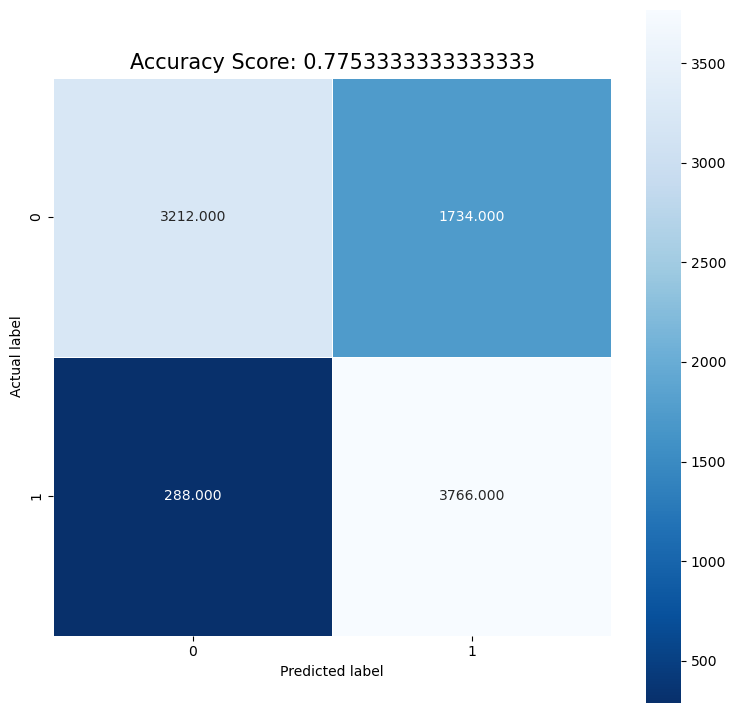

In [37]:
from sklearn import metrics

cm = metrics.confusion_matrix(y_test, predictions)
plt.figure(figsize=(9, 9))
sns.heatmap(cm, annot=True, fmt=".3f", linewidths=0.5, square=True, cmap="Blues_r")
plt.ylabel("Actual label")
plt.xlabel("Predicted label")
all_sample_title = "Accuracy Score: {0}".format(score)
plt.title(all_sample_title, size=15);

In [38]:
from sklearn.metrics import classification_report

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.92      0.65      0.76      4946
           1       0.68      0.93      0.79      4054

    accuracy                           0.78      9000
   macro avg       0.80      0.79      0.77      9000
weighted avg       0.81      0.78      0.77      9000



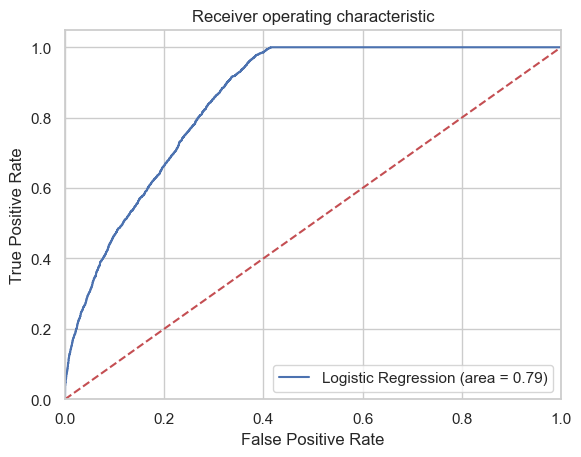

In [40]:
from sklearn.metrics import roc_auc_score, roc_curve

sns.set(style="whitegrid", color_codes=True)
logit_roc_auc = roc_auc_score(y_test, model.predict(X_test))
fpr, tpr, thresholds = roc_curve(y_test, model.predict_proba(X_test)[:, 1])
plt.figure()
plt.plot(fpr, tpr, label="Logistic Regression (area = %0.2f)" % logit_roc_auc)
plt.plot([0, 1], [0, 1], "r--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver operating characteristic")
plt.legend(loc="lower right")
plt.show()